In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

RNG = 42
np.random.seed(RNG)

Al igual que en la parte del análisis, construimos un nuevo notebook modificando a conveniencia las funciones para obtener los resultados de forma sencilla y directa.

In [2]:
# funciones necesarias
# función para aplanar como L como argumento 
def aplanar(A, L):
    return A.reshape(A.shape[0], L * L)

def cruce_05(temps, probs):
    temps, probs = np.asarray(temps), np.asarray(probs)
    for i in range(len(temps) - 1):
        if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]:
            return (temps[i] + (0.5 - probs[i]) *
                    (temps[i + 1] - temps[i]) / (probs[i + 1] - probs[i]))
    return np.nan

#===============================================================
# cargar dataframe y separar en X, y, T, m, realizacion
#===============================================================
def cargar_datos(ruta):
    datos = np.load(ruta, allow_pickle=False)
    X = datos["X"]
    y = datos["y"]
    T = datos["T"]
    m = datos["m"]
    realizacion = datos["realizacion"]

    Tc_exacto = float(datos["Tc"])
    L = int(datos["L"])

    print("X:", X.shape, X.dtype)
    print("y:", y.shape, "->", np.unique(y, return_counts=True))
    print("realizaciones:", np.unique(realizacion))
    print("Tc exacto (Onsager):", Tc_exacto)

    mask_train = np.isin(realizacion, [0, 1])
    mask_val   = realizacion == 2
    mask_test  = realizacion == 3

    X_train, y_train, T_train = aplanar(X[mask_train],L), y[mask_train], T[mask_train]
    X_val,   y_val,   T_val   = aplanar(X[mask_val], L),   y[mask_val],   T[mask_val]
    X_test,  y_test,  T_test  = aplanar(X[mask_test],L),  y[mask_test],  T[mask_test]

    for nombre, Xs, ys in [("train", X_train, y_train),
                        ("val",   X_val,   y_val),
                        ("test",  X_test,  y_test)]:
        print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, Tc_exacto

In [3]:
#=========================================================================
# función para entrenar un MLP y estimar Tc
#=========================================================================
'''le daamos hidden_layers_sizes como parametro, tambien random_state, y un booleano para
definir si se usa  prob_media o pred mean,  y la opción de graficar plots. El código es esencialmente el mismo, 
solo que ahora le damos también los datos extraidos del data set'''

def entrenar_mlp(X_train,X_val,X_test,y_train,y_val,y_test,hidden_layer_sizes,path, L, random_state=RNG, prob_media=True, plots=True):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=random_state,
    )
    
    model.fit(X_train, y_train)

    acc = {
        "train": model.score(X_train, y_train),
        "val":   model.score(X_val, y_val),
        "test":  model.score(X_test, y_test),
    }

    print(f"Arquitectura: {hidden_layer_sizes}")
    print(f"iteraciones: {model.n_iter_}   log-loss final: {model.loss_:.4f}")
    
    for k, v in acc.items():
        print(f"accuracy {k:5s}: {v:.4f}")

    #=========================================================================
    # barrido fino al rededor de Tc
    datos_tc = np.load(path, allow_pickle=False)
    X_tc = datos_tc["X"].reshape(datos_tc["X"].shape[0], L * L)
    T_tc = datos_tc["T"]
    realizacion_tc = datos_tc["realizacion"]
    y_ref_tc = datos_tc["y_ref"]

    print("\n" + "=" * 64)
    print("X_tc:", X_tc.shape)
    print("temperaturas:", np.unique(T_tc))

    # Probabilidad de la clase "desordenada" (y = 1)
    idx1 = list(model.classes_).index(1)
    p1_tc = model.predict_proba(X_tc)[:, idx1]

    # Chequeo con y_ref (NO usar para entrenar)
    pred_tc = (p1_tc >= 0.5).astype(int)
    print("accuracy vs y_ref (solo verificacion):",
        round((pred_tc == y_ref_tc).mean(), 4))


    #=========================================================================
    # Data frame para curva de probabilidad vs temperatura
    if prob_media:
        df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1_tc})

        resumen = (df.groupby(["realizacion", "T"])
                    .agg(prob_media=("prob", "mean"),
                        prob_std=("prob", "std"),
                        N=("prob", "size"))
                    .reset_index())
    else:
        df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "pred": pred_tc})

        resumen = (df.groupby(["realizacion", "T"])
                    .agg(pred_media=("pred", "mean"),
                        pred_std=("pred", "std"),
                        N=("pred", "size"))
                    .reset_index())


    #=========================================================================
    # Estimación de Tc por cada realización
    Tc_por_realizacion = []
    for r in np.unique(realizacion_tc):
        d = resumen[resumen.realizacion == r].sort_values("T")
        if prob_media:
            Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
        else:
            Tc_r = cruce_05(d["T"].to_numpy(), d["pred_media"].to_numpy())
    
        Tc_por_realizacion.append(Tc_r)
        print(f"realización {r}:  Tc = {Tc_r:.4f}")

    Tc_por_realizacion = np.array(Tc_por_realizacion)
    Tc_est = np.nanmean(Tc_por_realizacion)
    Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
    Tc_sem = Tc_std / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion)))

    print("\n" + "=" * 64)
    print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f}")
    print(f"Tc Onsager     = {Tc_exacto:.4f}")
    print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")

    #==========================================================================
    # graficas
    # perdida 
    if plots:
        fig, ax = plt.subplots(1, 3, figsize=(20, 6))
        ax[0].plot(model.loss_curve_)
        ax[0].set_xlabel("época")
        ax[0].set_ylabel("log-loss (entrenamiento)")
        ax[0].set_title(f"Curva de pérdida — {hidden_layer_sizes}")
        ax[0].grid(alpha=0.3)

        # Probabilidad vs temperatura
        ax[1].set_title("Probabilidad de la clase desordenada (y=1) vs Temperatura")
        ax[1].set_xlabel("Temperatura")
        ax[1].set_ylabel("<Probabilidad>")
        ax[1].plot(
            resumen["T"],
            resumen["prob_media"],
            'o',
            markersize=3,
            label="Probabilidad media"
        )
        ax[1].legend()

        # ─────────────────────────────
        for r in np.unique(realizacion_tc):

            d = resumen[resumen.realizacion == r].sort_values("T")

            ax[2].plot(d["T"],d["prob_media"],"o-", alpha=0.7, label=f"realización {r}")
            ax[2].axhline(0.5, ls="--", color="k")

            ax[2].axvline(Tc_est, ls="-", color="crimson", lw=2, label=fr"$T_c$ estimado = {Tc_est:.3f}")

        ax[2].axvline(Tc_exacto,ls=":",color="green",lw=2, label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")

        ax[2].set_xlabel("temperatura T")
        ax[2].set_ylabel(r"$\langle P(y=1\mid X)\rangle$")
        ax[2].set_title("Estimación de la temperatura crítica")
        ax[2].legend()
        ax[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return model, acc, realizacion_tc, resumen, Tc_est, Tc_std, Tc_sem

### modelo 10x10

In [4]:
# extraer datos
X_train10, X_val10, X_test10, y_train10, y_val10, y_test10, Tc_exacto = cargar_datos("Datos/Ising_dataset_L10.npz")

X: (1600, 10, 10) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022
train  X=(800, 100)  y=(800,)  clases=[400 400]
val    X=(400, 100)  y=(400,)  clases=[200 200]
test   X=(400, 100)  y=(400,)  clases=[200 200]


Arquitectura: (16, 8, 4)
iteraciones: 171   log-loss final: 0.0031
accuracy train: 1.0000
accuracy val  : 0.9650
accuracy test : 0.9600

X_tc: (6200, 100)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.7629
realización 0:  Tc = 2.3143
realización 1:  Tc = 2.3723
realización 2:  Tc = 2.3903
realización 3:  Tc = 2.3140

Tc estimado    = 2.3477 +/- 0.0197
Tc Onsager     = 2.2692
error relativo = 3.46 %


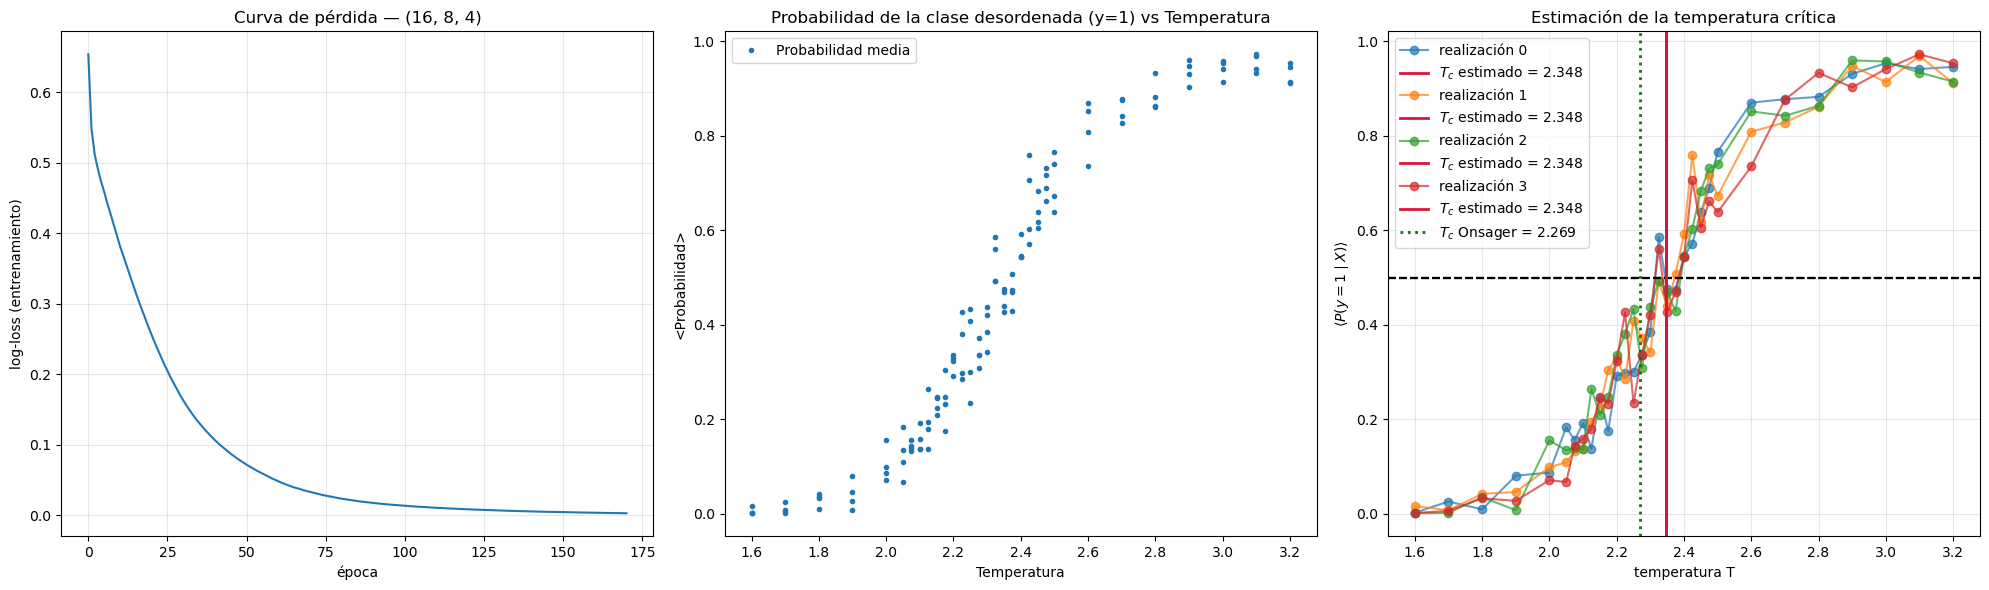

In [13]:
# aplicar el modelo 10x10
model_L10, acc_L10, realizacion_L10, resumen_L10, Tc_est_L10, Tc_std_L10, Tc_sem_L10 = entrenar_mlp(
    X_train10,X_val10,X_test10,y_train10,y_val10,y_test10,(16,8,4), "Datos/temperatura_critica10.npz", L=10,
    random_state=RNG, prob_media=True, plots=True)

### modelo 20x20

In [14]:
# extraer los datos
X_train20, X_val20, X_test20, y_train20, y_val20, y_test20, Tc_exacto = cargar_datos("Datos/Ising_dataset_L20.npz")

X: (1600, 20, 20) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022
train  X=(800, 400)  y=(800,)  clases=[400 400]
val    X=(400, 400)  y=(400,)  clases=[200 200]
test   X=(400, 400)  y=(400,)  clases=[200 200]


Arquitectura: (16, 8, 4)
iteraciones: 107   log-loss final: 0.0033
accuracy train: 0.9975
accuracy val  : 0.9650
accuracy test : 0.9750

X_tc: (6200, 400)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8279
realización 0:  Tc = 2.3221
realización 1:  Tc = 2.3167
realización 2:  Tc = 2.3472
realización 3:  Tc = 2.3372

Tc estimado    = 2.3308 +/- 0.0070
Tc Onsager     = 2.2692
error relativo = 2.71 %


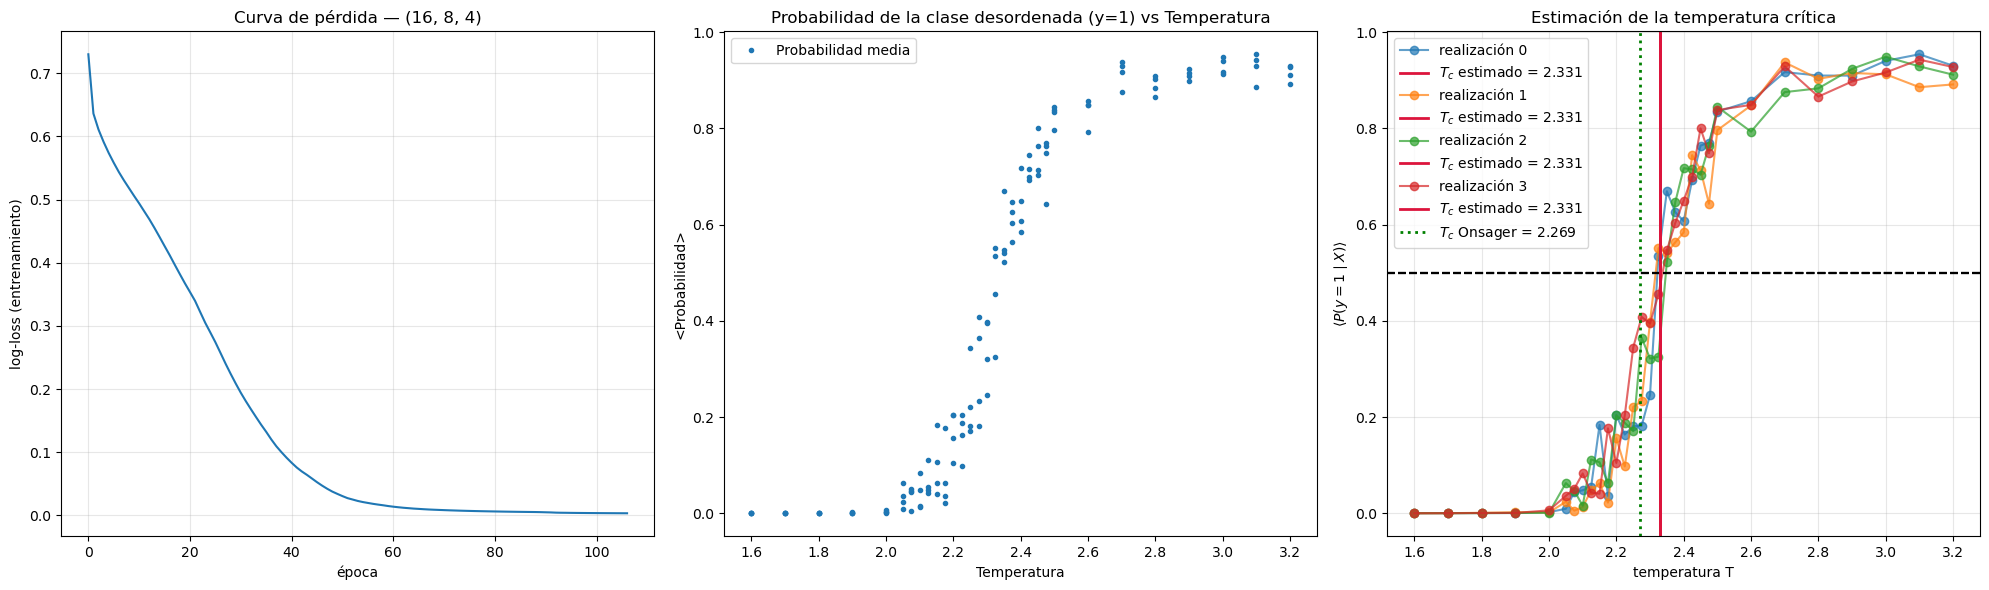

In [15]:
# aplicar modelo 20x20
model_L20, acc_L20, realizacion_L20, resumen_L20, Tc_est_L20, Tc_std_L20, Tc_sem_L20 = entrenar_mlp(
    X_train20,X_val20,X_test20,y_train20,y_val20,y_test20,(16,8,4), "Datos/temperatura_critica20.npz", L=20,
    random_state=RNG, prob_media=True, plots=True)

### modelo 30x30

In [16]:
# extraer los datos
X_train30, X_val30, X_test30, y_train30, y_val30, y_test30, Tc_exacto = cargar_datos("Datos/Ising_dataset_L30.npz")

X: (1600, 30, 30) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022
train  X=(800, 900)  y=(800,)  clases=[400 400]
val    X=(400, 900)  y=(400,)  clases=[200 200]
test   X=(400, 900)  y=(400,)  clases=[200 200]


Arquitectura: (16, 8, 4)
iteraciones: 90   log-loss final: 0.0023
accuracy train: 1.0000
accuracy val  : 0.9900
accuracy test : 0.9975

X_tc: (6200, 900)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8716
realización 0:  Tc = 2.3045
realización 1:  Tc = 2.3588
realización 2:  Tc = 2.3417
realización 3:  Tc = 2.3290

Tc estimado    = 2.3335 +/- 0.0114
Tc Onsager     = 2.2692
error relativo = 2.83 %


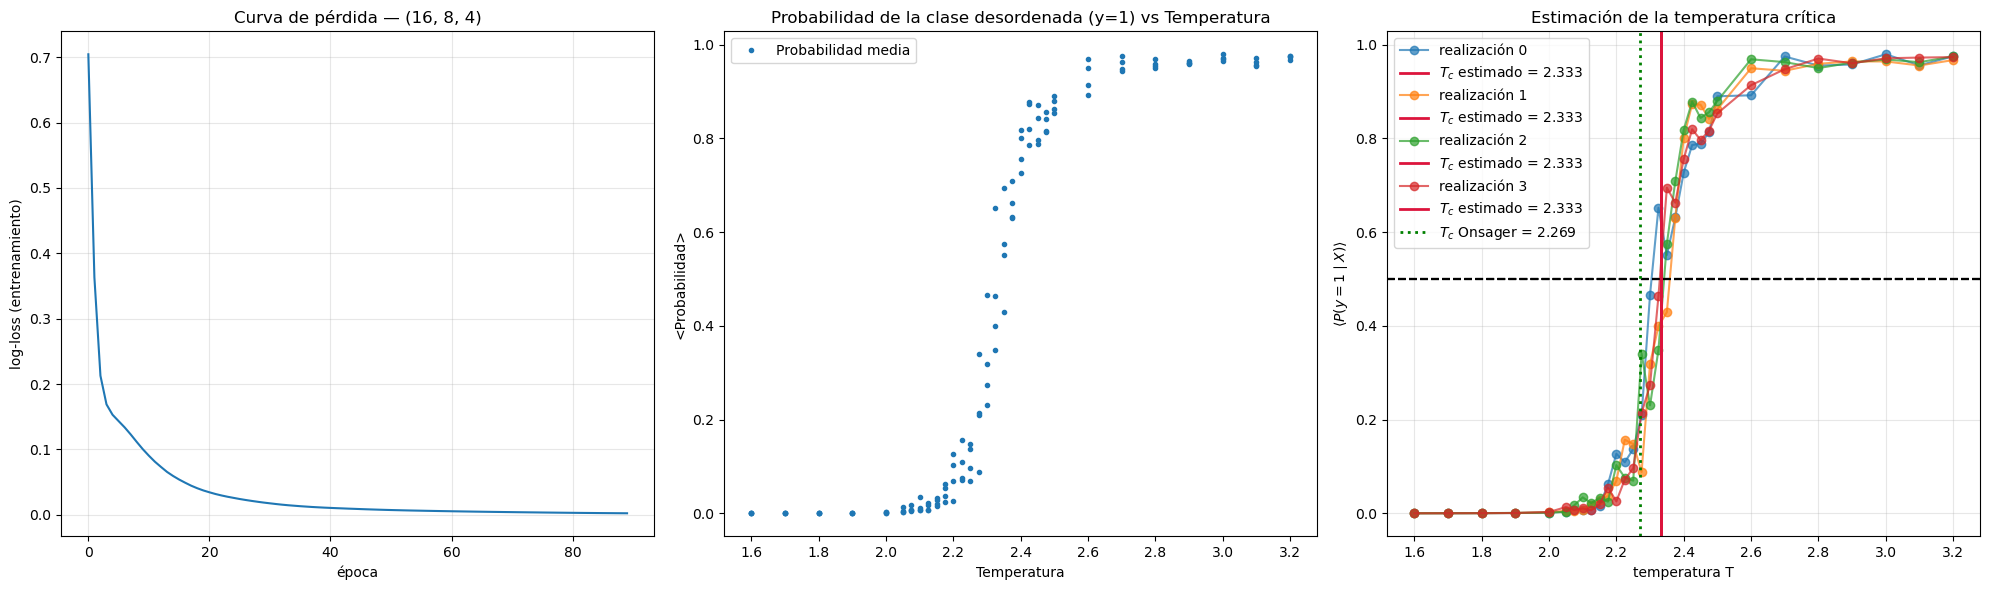

In [17]:
# aplicar modelo 30x30
model_L30, acc_L30, realizacion_L30, resumen_L30, Tc_est_L30, Tc_std_L30, Tc_sem_L30 = entrenar_mlp(
    X_train30,X_val30,X_test30,y_train30,y_val30,y_test30,(16,8,4), "Datos/temperatura_critica30.npz", L=30,
    random_state=RNG, prob_media=True, plots=True)

### Bonus: modelo 100x100

In [18]:
X_train100, X_val100, X_test100, y_train100, y_val100, y_test100, Tc_exacto = cargar_datos("Datos/Ising_dataset_L100.npz")

X: (1600, 100, 100) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022
train  X=(800, 10000)  y=(800,)  clases=[400 400]
val    X=(400, 10000)  y=(400,)  clases=[200 200]
test   X=(400, 10000)  y=(400,)  clases=[200 200]


Arquitectura: (16, 8, 4)
iteraciones: 95   log-loss final: 0.0031
accuracy train: 0.9975
accuracy val  : 0.8850
accuracy test : 0.8400

X_tc: (6200, 10000)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8148
realización 0:  Tc = 2.3296
realización 1:  Tc = 2.2889
realización 2:  Tc = 2.2930
realización 3:  Tc = 2.3184

Tc estimado    = 2.3075 +/- 0.0099
Tc Onsager     = 2.2692
error relativo = 1.69 %


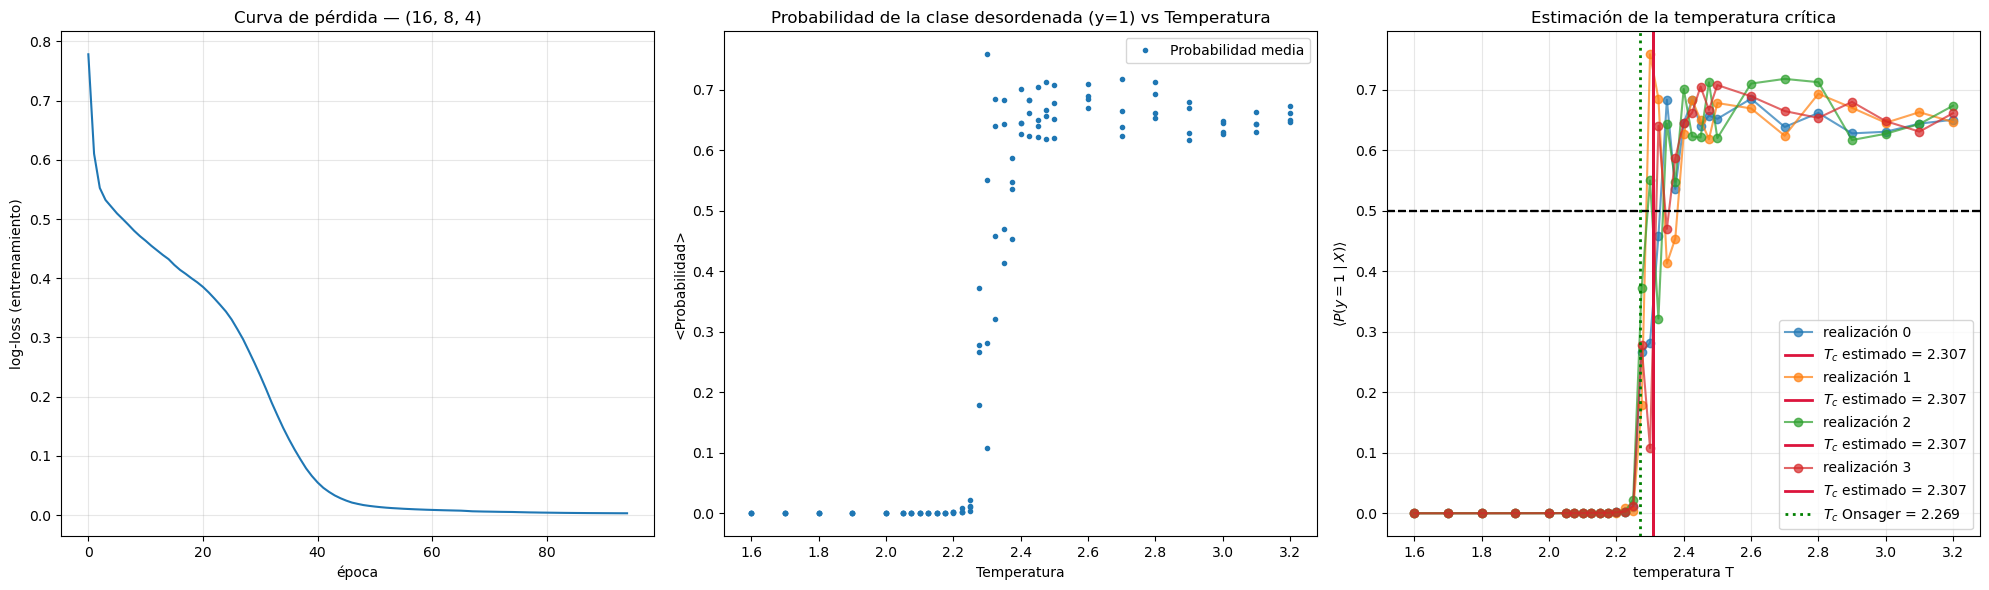

In [ ]:
# modelo 100x100
model_L100, acc_L100, realizacion_L100, resumen_L100, Tc_est_L100, Tc_std_L100, Tc_sem_L100 = entrenar_mlp(
    X_train100,X_val100,X_test100,y_train100,y_val100,y_test100,(16,8,4), "Datos/temperatura_critica100.npz", L=100,
    random_state=RNG, prob_media=True, plots=True)

In [12]:
print("\n" + "=" * 64)
print("L = 10")
print(f"Tc estimado = {Tc_est_L10:.4f}")
print("\n" + "=" * 64)
print("L = 20")
print(f"Tc estimado = {Tc_est_L20:.4f}")
print("\n" + "=" * 64)
print("L = 30")
print(f"Tc estimado = {Tc_est_L30:.4f}")
print("\n" + "=" * 64)
print("L = 100")
print(f"Tc estimado = {Tc_est_L100:.4f}")


L = 10
Tc estimado = 2.3477

L = 20
Tc estimado = 2.3308

L = 30
Tc estimado = 2.3335

L = 100
Tc estimado = 2.3075


La temperatura crítica estimada da mejor con el modelo de la red de $100 \times 100$. 
Para valores pequeños de $L: {10, 20, 30}$, la conclusión no es directa. El sistema sigue siendo pequeño y las fluctuaciones de tamaño hacen que la estimación de $T_c$ sea difícil de predecir, y la transición entre las 2 fases es más difícil de distinguir.

Adicionalmente, el modelo de Osnager viene del límite termodinámico, donde $L \to \infty $, lo que se evidencia también en el error de estimación del modelo.